In [1]:
#PROMPT CHAINING: calling llms many times to decompose task
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import GoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

c:\python\Python311\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
load_dotenv()
model=GoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [17]:
#define state
class blogstate(TypedDict):
    title:str
    outline:str
    blog:str

In [24]:
#define node functions
def create_outline(state:blogstate)-> blogstate:
    #fetch title
    title=state['title']
    #call model
    prompt=f"Create a detailed outline for a blog on the topic:{title}"
    outline= model.invoke(prompt)
    #update state
    state['outline']=outline
    return state

def create_blog(state:blogstate)-> blogstate:
    #fetch outline
    title=state['title']
    outline=state['outline']
    #call model
    prompt=f"write a blog on the title: {title} using the following outline: \n  {outline}"
    blog=model.invoke(prompt)
    #update state
    state['blog']= blog
    return state

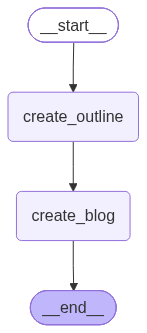

In [25]:
#load graph
graph = StateGraph(blogstate)
#add nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
#add edges 
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog',END)
#compile 
graph.compile()

In [26]:
#execute workflow
workflow=graph.compile()
initial_state={'title':'Rise of AI in India'}
final_state=workflow.invoke(initial_state)
print(final_state['blog'])

## India's AI Revolution: From Tech Hub to Intelligent Nation

Imagine a nation where traffic flows seamlessly, healthcare reaches every corner, and education is personalized for every child. This isn't science fiction; it's the emerging reality powered by Artificial Intelligence in India. In recent years, the term "Artificial Intelligence" or AI has transitioned from a futuristic concept to a tangible force reshaping our world. At its core, AI refers to the simulation of human intelligence processes by machines, especially computer systems, which includes learning, problem-solving, and decision-making. India, a nation already renowned for its technological prowess, is now standing at the cusp of an AI revolution, poised to leverage this transformative technology for unprecedented growth and societal advancement. In this blog, we'll explore the key drivers behind India's AI surge, delve into its impact across various sectors, and discuss the crucial steps being taken to harness its ful

In [27]:
print(final_state['outline'])

## Blog Outline: The Rise of AI in India - A Nation Embracing Intelligence

**I. Catchy Title Options (Choose one or a variation):**

* The AI Awakening: How India is Leading the Charge in Artificial Intelligence
* India's AI Revolution: From Tech Hub to Intelligent Nation
* Decoding India's AI Boom: Opportunities, Challenges, and the Road Ahead
* Intelligent India: Understanding the Impact of AI on the Nation's Future

**II. Introduction (Approx. 200-300 words)**

*   **Hook:** Start with a compelling statistic, a relatable anecdote, or a thought-provoking question about AI's presence in our lives. (e.g., "Imagine a nation where traffic flows seamlessly, healthcare reaches every corner, and education is personalized for every child. This isn't science fiction; it's the emerging reality powered by Artificial Intelligence in India.")
*   **Briefly define AI:** A simple, accessible definition for the general reader.
*   **Thesis Statement:** Clearly state the blog's main argument – that 